<a href="https://colab.research.google.com/github/dwi-aprilianto/Clustering_DBSCAN/blob/main/Clustering_KMeans_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. SETUP DAN MOUNT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# SETUP PATH

BASE_DIR = Path("/content/drive/MyDrive/Clustering_TA_Revision")

RAW_DATA_PATH = BASE_DIR / "penjualan_tiket_raw.xlsx"

PROCESSED_PATH = BASE_DIR / "penjualan_tiket_clean.csv"
KMEANS_RESULT_PATH = BASE_DIR / "penjualan_tiket_kmeans.csv"

ELBOW_RESULT_PATH = BASE_DIR / "hasil_elbow_kmeans.csv"
HPO_RESULT_PATH = BASE_DIR / "hasil_hpo_kmeans.csv"

MODEL_PATH = BASE_DIR / "kmeans_model.pkl"
SCALER_PATH = BASE_DIR / "scaler.pkl"

VISUAL_DIR = BASE_DIR / "visualisasi_kmeans"
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Raw data path:", RAW_DATA_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base directory: /content/drive/MyDrive/Clustering_TA_Revision
Raw data path: /content/drive/MyDrive/Clustering_TA_Revision/penjualan_tiket_raw.xlsx


2. LOAD DATA AWAL DAN EDA

=== INFORMASI DATASET AWAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   No         9579 non-null   int64 
 1   Pembelian  9579 non-null   object
 2   Kategori   9579 non-null   object
 3   Tanggal    9579 non-null   object
 4   Jumlah     9579 non-null   int64 
 5   Total      9579 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 449.1+ KB

=== 5 DATA TERATAS ===


,No,Pembelian,Kategori,Tanggal,Jumlah,Total
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 11:15:00,13,325000
1,2,TIKET MANCANEGARA,Mancanegara,05-05-2025 10:28:00,1,20000
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 10:00:00,1,25000
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 09:57:00,7,175000
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,04-05-2025 11:21:00,4,100000



=== JUMLAH BARIS DAN KOLOM ===
Jumlah baris : 9579
Jumlah kolom : 6

=== MISSING VALUES ===


,0
No,0
Pembelian,0
Kategori,0
Tanggal,0
Jumlah,0
Total,0



=== DATA DUPLIKAT ===
Jumlah data duplikat: 0

=== STATISTIK DESKRIPTIF DATA AWAL ===


,No,Pembelian,Kategori,Tanggal,Jumlah,Total
count,9579.000000,9579,9579,9579,9579.000000,9.579000e+03
unique,NaN,11,4,8052,NaN,NaN
top,NaN,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,27-07-2024 17:00:00,NaN,NaN
freq,NaN,2576,6741,7,NaN,NaN
mean,4790.000000,NaN,NaN,NaN,7.677419,1.556783e+05
std,2765.363448,NaN,NaN,NaN,20.015100,3.900012e+05
min,1.000000,NaN,NaN,NaN,1.000000,1.000000e+04
25%,2395.500000,NaN,NaN,NaN,2.000000,4.000000e+04
50%,4790.000000,NaN,NaN,NaN,3.000000,6.000000e+04
75%,7184.500000,NaN,NaN,NaN,6.000000,1.200000e+05


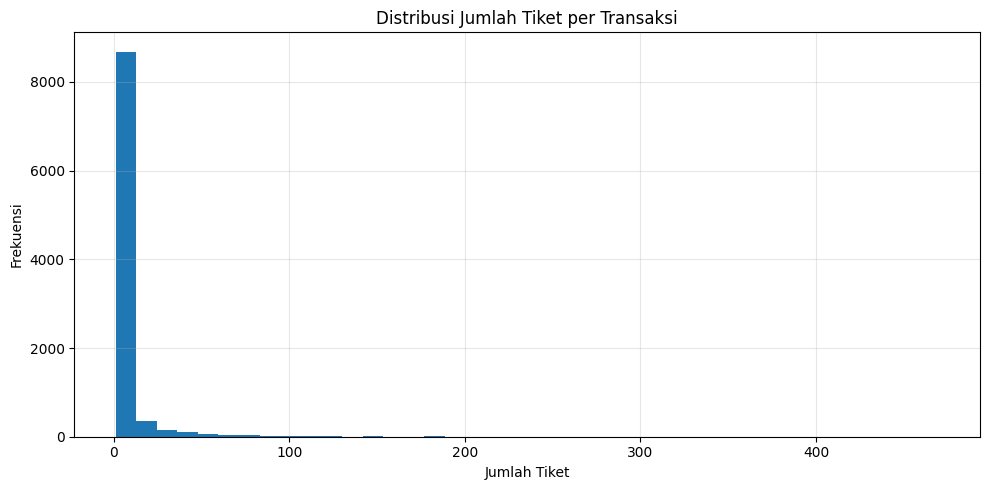

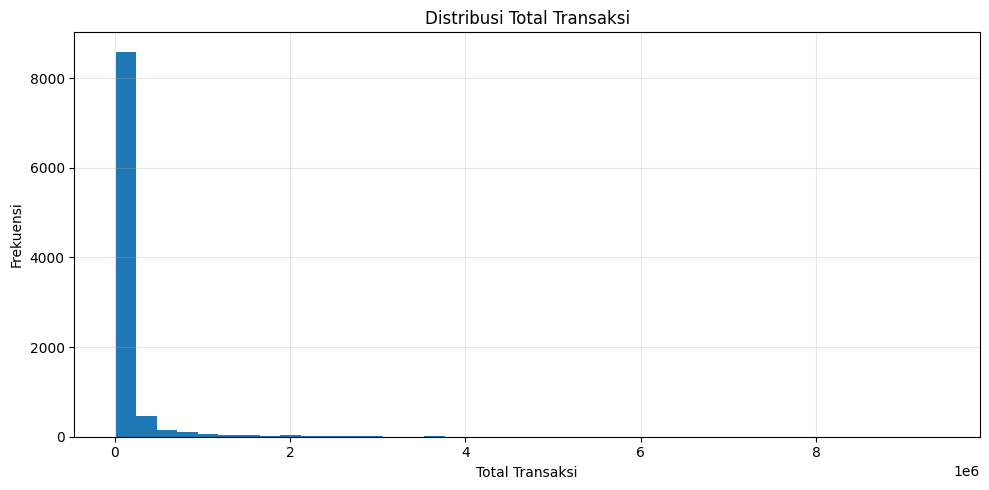

In [ ]:
df_raw = pd.read_excel(RAW_DATA_PATH)

print("=== INFORMASI DATASET AWAL ===")
df_raw.info()

print("\n=== 5 DATA TERATAS ===")
display(df_raw.head())

print("\n=== JUMLAH BARIS DAN KOLOM ===")
print(f"Jumlah baris : {df_raw.shape[0]}")
print(f"Jumlah kolom : {df_raw.shape[1]}")

print("\n=== MISSING VALUES ===")
display(df_raw.isna().sum())

print("\n=== DATA DUPLIKAT ===")
print(f"Jumlah data duplikat: {df_raw.duplicated().sum()}")

print("\n=== STATISTIK DESKRIPTIF DATA AWAL ===")
display(df_raw.describe(include="all"))

# Visualisasi distribusi jumlah tiket
plt.figure(figsize=(10, 5))
plt.hist(df_raw["Jumlah"], bins=40)
plt.title("Distribusi Jumlah Tiket per Transaksi")
plt.xlabel("Jumlah Tiket")
plt.ylabel("Frekuensi")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisasi distribusi total transaksi
plt.figure(figsize=(10, 5))
plt.hist(df_raw["Total"], bins=40)
plt.title("Distribusi Total Transaksi")
plt.xlabel("Total Transaksi")
plt.ylabel("Frekuensi")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

3. PREPROCESSING DAN FEATURE ENGINEERING

In [ ]:
df = df_raw.copy()

# STANDARDISASI NAMA KOLOM

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("=== NAMA KOLOM SETELAH STANDARDISASI ===")
print(df.columns.tolist())

# VALIDASI KOLOM UTAMA

required_columns = [
    "pembelian",
    "kategori",
    "tanggal",
    "jumlah",
    "total"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Kolom berikut tidak ditemukan pada dataset: {missing_columns}")

# KONVERSI TIPE DATA

df["tanggal"] = pd.to_datetime(
    df["tanggal"],
    dayfirst=True,
    errors="coerce"
)

df["jumlah"] = pd.to_numeric(
    df["jumlah"],
    errors="coerce"
)

df["total"] = pd.to_numeric(
    df["total"],
    errors="coerce"
)

# PEMBERSIHAN DATA

df = df.dropna(
    subset=[
        "tanggal",
        "jumlah",
        "total"
    ]
)

df = df[
    (df["jumlah"] > 0) &
    (df["total"] > 0)
].copy()

df = df.drop_duplicates().copy()

# FEATURE ENGINEERING

df["tahun"] = df["tanggal"].dt.year
df["bulan"] = df["tanggal"].dt.month
df["hari"] = df["tanggal"].dt.day
df["nama_hari"] = df["tanggal"].dt.day_name()
df["jam"] = df["tanggal"].dt.hour

df["is_weekend"] = df["nama_hari"].isin(
    ["Saturday", "Sunday"]
).astype(int)

df["harga_per_tiket"] = np.where(
    df["jumlah"] > 0,
    df["total"] / df["jumlah"],
    np.nan
)

# Label tambahan untuk analisis deskriptif, bukan fitur model utama
df["volume_penjualan"] = pd.cut(
    df["jumlah"],
    bins=[0, 2, 5, 10, 50, np.inf],
    labels=[
        "Sangat Rendah",
        "Rendah",
        "Sedang",
        "Tinggi",
        "Sangat Tinggi"
    ]
)

# Bersihkan kembali apabila ada infinite atau missing
df = (
    df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("\n=== DATA SETELAH PREPROCESSING DAN FEATURE ENGINEERING ===")
display(df.head())

print("\n=== INFO DATA SETELAH PREPROCESSING ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF FITUR NUMERIK ===")
display(df[["jumlah", "total", "harga_per_tiket", "jam", "is_weekend"]].describe())

# Simpan data clean
df.to_csv(PROCESSED_PATH, index=False)
print(f"\nData clean disimpan di: {PROCESSED_PATH}")

=== NAMA KOLOM SETELAH STANDARDISASI ===
['no', 'pembelian', 'kategori', 'tanggal', 'jumlah', 'total']

=== DATA SETELAH PREPROCESSING DAN FEATURE ENGINEERING ===


,no,pembelian,kategori,tanggal,jumlah,total,tahun,bulan,hari,nama_hari,jam,is_weekend,harga_per_tiket,volume_penjualan
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 11:15:00,13,325000,2025,5,5,Monday,11,0,25000.0,Tinggi
1,2,TIKET MANCANEGARA,Mancanegara,2025-05-05 10:28:00,1,20000,2025,5,5,Monday,10,0,20000.0,Sangat Rendah
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 10:00:00,1,25000,2025,5,5,Monday,10,0,25000.0,Sangat Rendah
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 09:57:00,7,175000,2025,5,5,Monday,9,0,25000.0,Sedang
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-04 11:21:00,4,100000,2025,5,4,Sunday,11,1,25000.0,Rendah



=== INFO DATA SETELAH PREPROCESSING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   no                9579 non-null   int64         
 1   pembelian         9579 non-null   object        
 2   kategori          9579 non-null   object        
 3   tanggal           9579 non-null   datetime64[ns]
 4   jumlah            9579 non-null   int64         
 5   total             9579 non-null   int64         
 6   tahun             9579 non-null   int32         
 7   bulan             9579 non-null   int32         
 8   hari              9579 non-null   int32         
 9   nama_hari         9579 non-null   object        
 10  jam               9579 non-null   int32         
 11  is_weekend        9579 non-null   int64         
 12  harga_per_tiket   9579 non-null   float64       
 13  volume_penjualan  9579 non-null   cat

,jumlah,total,harga_per_tiket,jam,is_weekend
count,9579.000000,9.579000e+03,9579.000000,9579.00000,9579.000000
mean,7.677419,1.556783e+05,20752.385599,12.38835,0.439190
std,20.015100,3.900012e+05,6024.721057,3.03772,0.496314
min,1.000000,1.000000e+04,10000.000000,0.00000,0.000000
25%,2.000000,4.000000e+04,15000.000000,10.00000,0.000000
50%,3.000000,6.000000e+04,20000.000000,12.00000,0.000000
75%,6.000000,1.200000e+05,25000.000000,14.00000,1.000000
max,470.000000,9.400000e+06,30000.000000,23.00000,1.000000



Data clean disimpan di: /content/drive/MyDrive/Clustering_TA_Revision/penjualan_tiket_clean.csv


4. SELEKSI FITUR CLUSTERING

In [ ]:
features = [
    "jumlah",
    "total",
    "harga_per_tiket",
    "is_weekend",
    "jam"
]

missing_features = [
    feature for feature in features
    if feature not in df.columns
]

if missing_features:
    raise ValueError(f"Fitur berikut tidak ditemukan: {missing_features}")

X = df[features].copy()

print("=== FITUR YANG DIGUNAKAN UNTUK CLUSTERING ===")
print(features)

print("\n=== PREVIEW DATA FITUR ===")
display(X.head())

print("\n=== STATISTIK FITUR CLUSTERING ===")
display(X.describe())

=== FITUR YANG DIGUNAKAN UNTUK CLUSTERING ===
['jumlah', 'total', 'harga_per_tiket', 'is_weekend', 'jam']

=== PREVIEW DATA FITUR ===


,jumlah,total,harga_per_tiket,is_weekend,jam
0,13,325000,25000.0,0,11
1,1,20000,20000.0,0,10
2,1,25000,25000.0,0,10
3,7,175000,25000.0,0,9
4,4,100000,25000.0,1,11



=== STATISTIK FITUR CLUSTERING ===


,jumlah,total,harga_per_tiket,is_weekend,jam
count,9579.000000,9.579000e+03,9579.000000,9579.000000,9579.00000
mean,7.677419,1.556783e+05,20752.385599,0.439190,12.38835
std,20.015100,3.900012e+05,6024.721057,0.496314,3.03772
min,1.000000,1.000000e+04,10000.000000,0.000000,0.00000
25%,2.000000,4.000000e+04,15000.000000,0.000000,10.00000
50%,3.000000,6.000000e+04,20000.000000,0.000000,12.00000
75%,6.000000,1.200000e+05,25000.000000,1.000000,14.00000
max,470.000000,9.400000e+06,30000.000000,1.000000,23.00000


5. SCALING DATA

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("=== HASIL SCALING DATA ===")
print("Shape X:", X.shape)
print("Shape X_scaled:", X_scaled.shape)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("\n=== PREVIEW DATA SETELAH SCALING ===")
display(X_scaled_df.head())

print("\n=== STATISTIK DATA SETELAH SCALING ===")
display(X_scaled_df.describe().round(4))

=== HASIL SCALING DATA ===
Shape X: (9579, 5)
Shape X_scaled: (9579, 5)

=== PREVIEW DATA SETELAH SCALING ===


,jumlah,total,harga_per_tiket,is_weekend,jam
0,0.265942,0.434179,0.705068,-0.884949,-0.457061
1,-0.333637,-0.347910,-0.124890,-0.884949,-0.786272
2,-0.333637,-0.335089,0.705068,-0.884949,-0.786272
3,-0.033847,0.049545,0.705068,-0.884949,-1.115483
4,-0.183742,-0.142772,0.705068,1.130009,-0.457061



=== STATISTIK DATA SETELAH SCALING ===


,jumlah,total,harga_per_tiket,is_weekend,jam
count,9579.0000,9579.0000,9579.0000,9579.0000,9579.0000
mean,-0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001
min,-0.3336,-0.3736,-1.7848,-0.8849,-4.0784
25%,-0.2837,-0.2966,-0.9548,-0.8849,-0.7863
50%,-0.2337,-0.2453,-0.1249,-0.8849,-0.1278
75%,-0.0838,-0.0915,0.7051,1.1300,0.5306
max,23.0999,23.7046,1.5350,1.1300,3.4935


6. ELBOW METHOD

=== ELBOW METHOD K-MEANS ===

=== HASIL ELBOW METHOD ===


,n_clusters,inertia
0,1,47895.000000
1,2,35318.833152
2,3,25892.184525
3,4,21531.441764
4,5,18439.258379
5,6,15535.332470
6,7,12984.413996
7,8,11483.855942
8,9,10390.651280
9,10,9625.717449


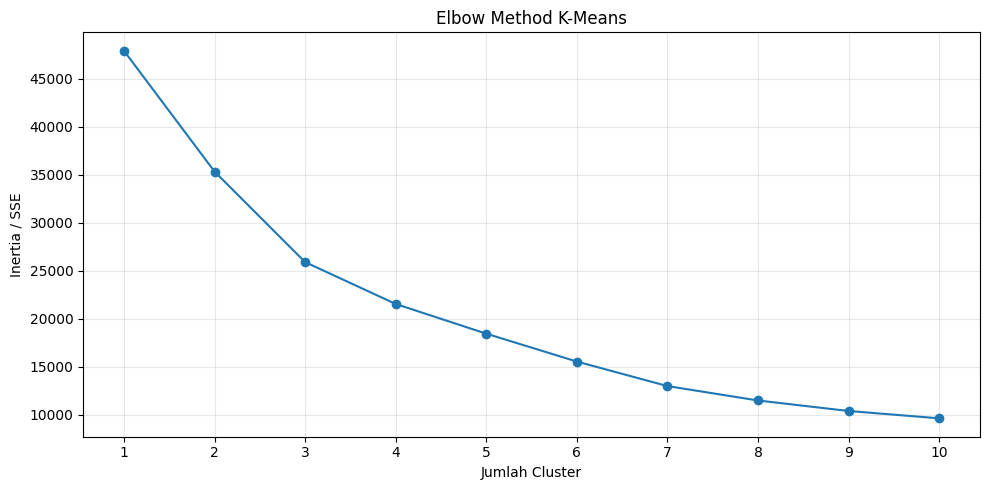


Jumlah cluster yang digunakan berdasarkan Elbow Method: k = 3
Hasil Elbow Method disimpan di: /content/drive/MyDrive/Clustering_TA_Revision/hasil_elbow_kmeans.csv


In [ ]:
print("=== ELBOW METHOD K-MEANS ===")

elbow_range = range(1, 11)
elbow_results = []

for k in elbow_range:
    kmeans_elbow = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        algorithm="lloyd",
        random_state=42
    )

    kmeans_elbow.fit(X_scaled)

    elbow_results.append({
        "n_clusters": k,
        "inertia": kmeans_elbow.inertia_
    })

elbow_df = pd.DataFrame(elbow_results)

print("\n=== HASIL ELBOW METHOD ===")
display(elbow_df)

# VISUALISASI ELBOW METHOD

plt.figure(figsize=(10, 5))
plt.plot(
    elbow_df["n_clusters"],
    elbow_df["inertia"],
    marker="o"
)
plt.title("Elbow Method K-Means")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia / SSE")
plt.xticks(list(elbow_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(VISUAL_DIR / "elbow_method_kmeans.png", dpi=300)
plt.show()

# PENENTUAN JUMLAH CLUSTER

selected_k = 3

print(f"\nJumlah cluster yang digunakan berdasarkan Elbow Method: k = {selected_k}")

elbow_df.to_csv(ELBOW_RESULT_PATH, index=False)
print(f"Hasil Elbow Method disimpan di: {ELBOW_RESULT_PATH}")

In [ ]:
# 7. HYPERPARAMETER OPTIMIZATION K-MEANS

print("=== HYPERPARAMETER OPTIMIZATION K-MEANS ===")

start_time = time.time()

# Jumlah cluster tidak lagi dicari melalui HPO.
# Jumlah cluster sudah ditentukan menggunakan Elbow Method.
cluster_range = [selected_k]

init_methods = [
    "k-means++",
    "random"
]

n_inits = [
    10,
    20,
    50
]

max_iters = [
    300,
    500
]

algorithms = [
    "lloyd",
    "elkan"
]

hpo_results = []

for n_clusters in cluster_range:
    for init in init_methods:
        for n_init in n_inits:
            for max_iter in max_iters:
                for algorithm in algorithms:

                    try:
                        kmeans = KMeans(
                            n_clusters=n_clusters,
                            init=init,
                            n_init=n_init,
                            max_iter=max_iter,
                            algorithm=algorithm,
                            random_state=42
                        )

                        labels = kmeans.fit_predict(X_scaled)

                        silhouette = silhouette_score(
                            X_scaled,
                            labels
                        )

                        dbi = davies_bouldin_score(
                            X_scaled,
                            labels
                        )

                        chi = calinski_harabasz_score(
                            X_scaled,
                            labels
                        )

                        inertia = kmeans.inertia_

                        hpo_results.append({
                            "n_clusters": n_clusters,
                            "init": init,
                            "n_init": n_init,
                            "max_iter": max_iter,
                            "algorithm": algorithm,
                            "silhouette_score": silhouette,
                            "davies_bouldin_score": dbi,
                            "calinski_harabasz_score": chi,
                            "inertia": inertia
                        })

                    except Exception as e:
                        print(
                            f"Error pada konfigurasi "
                            f"k={n_clusters}, init={init}, "
                            f"n_init={n_init}, max_iter={max_iter}, "
                            f"algorithm={algorithm}: {e}"
                        )

end_time = time.time()

hpo_results = pd.DataFrame(hpo_results)

# Ranking utama menggunakan Silhouette Score tertinggi,
# lalu DBI terendah sebagai pembanding tambahan.
hpo_results = hpo_results.sort_values(
    by=[
        "silhouette_score",
        "davies_bouldin_score",
        "calinski_harabasz_score"
    ],
    ascending=[
        False,
        True,
        False
    ]
).reset_index(drop=True)

print("\n=== TOP 10 HASIL HPO K-MEANS ===")
display(hpo_results.head(10))

print(f"\nWaktu proses HPO: {end_time - start_time:.2f} detik")

hpo_results.to_csv(HPO_RESULT_PATH, index=False)
print(f"Hasil HPO K-Means disimpan di: {HPO_RESULT_PATH}")

=== HYPERPARAMETER OPTIMIZATION K-MEANS ===

=== TOP 10 HASIL HPO K-MEANS ===


,n_clusters,init,n_init,max_iter,algorithm,silhouette_score,davies_bouldin_score,calinski_harabasz_score,inertia
0,3,random,10,300,lloyd,0.341098,1.108475,4068.767829,25892.206325
1,3,random,10,300,elkan,0.341098,1.108475,4068.767829,25892.206325
2,3,random,10,500,lloyd,0.341098,1.108475,4068.767829,25892.206325
3,3,random,10,500,elkan,0.341098,1.108475,4068.767829,25892.206325
4,3,random,20,300,lloyd,0.341098,1.108475,4068.767829,25892.206325
5,3,random,20,300,elkan,0.341098,1.108475,4068.767829,25892.206325
6,3,random,20,500,lloyd,0.341098,1.108475,4068.767829,25892.206325
7,3,random,20,500,elkan,0.341098,1.108475,4068.767829,25892.206325
8,3,k-means++,10,300,lloyd,0.341075,1.108173,4068.775286,25892.184525
9,3,k-means++,10,300,elkan,0.341075,1.108173,4068.775286,25892.184525



Waktu proses HPO: 44.47 detik
Hasil HPO K-Means disimpan di: /content/drive/MyDrive/Clustering_TA_Revision/hasil_hpo_kmeans.csv


8. TRAINING FINAL MODEL K-MEANS

In [ ]:
best_params = hpo_results.iloc[0]

print("=== PARAMETER TERBAIK K-MEANS ===")
display(best_params)

best_kmeans = KMeans(
    n_clusters=int(best_params["n_clusters"]),
    init=best_params["init"],
    n_init=int(best_params["n_init"]),
    max_iter=int(best_params["max_iter"]),
    algorithm=best_params["algorithm"],
    random_state=42
)

final_labels = best_kmeans.fit_predict(X_scaled)

df["cluster_kmeans"] = final_labels
df["cluster"] = final_labels

print("\n=== DISTRIBUSI CLUSTER K-MEANS ===")
display(df["cluster_kmeans"].value_counts().sort_index())

print("\n=== PERSENTASE CLUSTER K-MEANS ===")
display(
    (df["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

=== PARAMETER TERBAIK K-MEANS ===


,0
n_clusters,3
init,random
n_init,10
max_iter,300
algorithm,lloyd
silhouette_score,0.341098
davies_bouldin_score,1.108475
calinski_harabasz_score,4068.767829
inertia,25892.206325



=== DISTRIBUSI CLUSTER K-MEANS ===


,count
cluster_kmeans,
0,4150
1,175
2,5254



=== PERSENTASE CLUSTER K-MEANS ===


,proportion
cluster_kmeans,
0,43.32
1,1.83
2,54.85


9. EVALUASI PERFORMANCE K-MEANS

In [ ]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    final_labels
)

kmeans_dbi = davies_bouldin_score(
    X_scaled,
    final_labels
)

kmeans_chi = calinski_harabasz_score(
    X_scaled,
    final_labels
)

kmeans_inertia = best_kmeans.inertia_

evaluation_kmeans = pd.DataFrame({
    "Model": ["K-Means"],
    "n_clusters": [best_kmeans.n_clusters],
    "Silhouette Score": [kmeans_silhouette],
    "Davies-Bouldin Index": [kmeans_dbi],
    "Calinski-Harabasz Index": [kmeans_chi],
    "Inertia": [kmeans_inertia]
})

print("=== HASIL EVALUASI PERFORMANCE K-MEANS ===")
display(evaluation_kmeans.round(4))

print(f"Silhouette Score        : {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index    : {kmeans_dbi:.4f}")
print(f"Calinski-Harabasz Index : {kmeans_chi:.4f}")
print(f"Inertia                 : {kmeans_inertia:.4f}")

# SILHOUETTE SCORE PER DATA

silhouette_values = silhouette_samples(
    X_scaled,
    final_labels
)

df["silhouette_score"] = silhouette_values

print("\n=== RATA-RATA SILHOUETTE SCORE PER CLUSTER ===")
display(
    df
    .groupby("cluster_kmeans")["silhouette_score"]
    .agg(["mean", "min", "max", "count"])
    .round(4)
)

=== HASIL EVALUASI PERFORMANCE K-MEANS ===


,Model,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Inertia
0,K-Means,3,0.3411,1.1085,4068.7678,25892.2063


Silhouette Score        : 0.3411
Davies-Bouldin Index    : 1.1085
Calinski-Harabasz Index : 4068.7678
Inertia                 : 25892.2063

=== RATA-RATA SILHOUETTE SCORE PER CLUSTER ===


,mean,min,max,count
cluster_kmeans,,,,
0,0.3520,0.0792,0.4633,4150
1,0.3322,-0.1160,0.5621,175
2,0.3328,0.0709,0.4397,5254


10. VISUALISASI CLUSTER

=== EXPLAINED VARIANCE PCA ===
PCA 1: 0.3948
PCA 2: 0.2222
Total: 0.6171


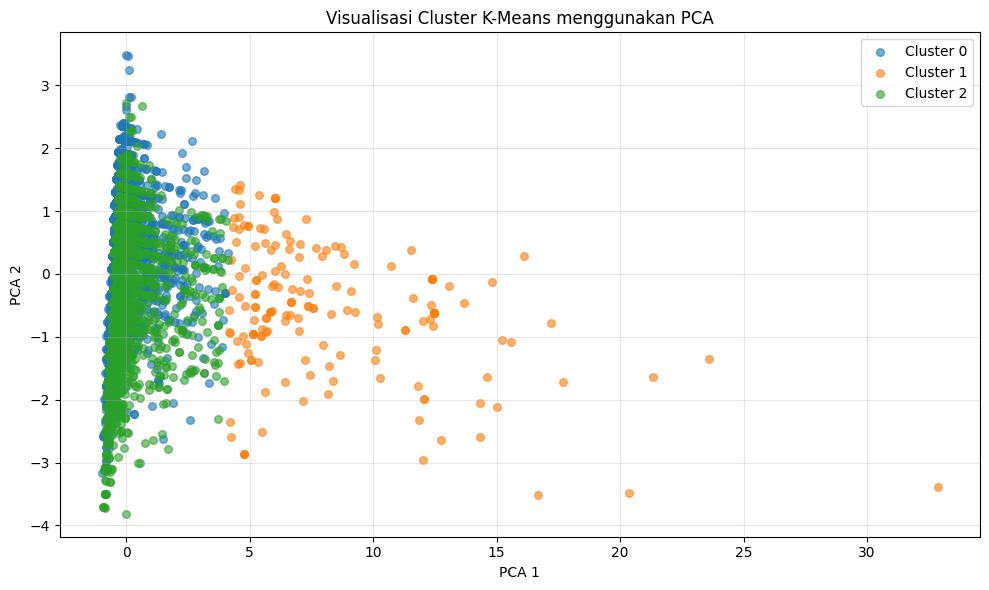

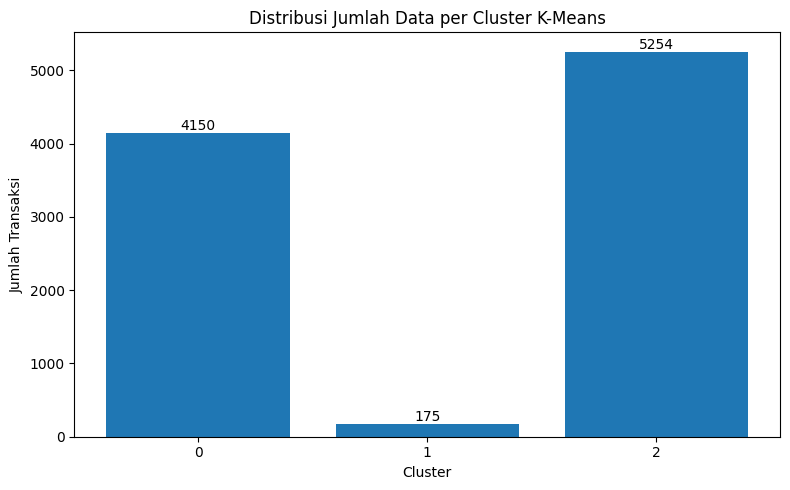

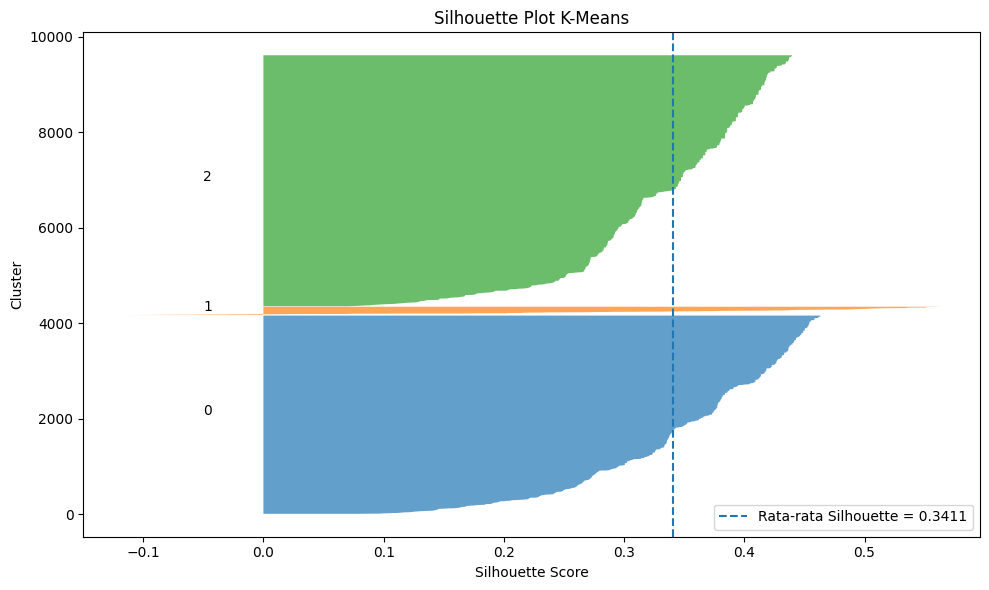

In [ ]:
# PCA UNTUK VISUALISASI 2D

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

pca_explained = pca.explained_variance_ratio_

print("=== EXPLAINED VARIANCE PCA ===")
print(f"PCA 1: {pca_explained[0]:.4f}")
print(f"PCA 2: {pca_explained[1]:.4f}")
print(f"Total: {pca_explained.sum():.4f}")

# SCATTER PLOT CLUSTER

plt.figure(figsize=(10, 6))

for cluster_id in sorted(df["cluster_kmeans"].unique()):
    cluster_data = df[df["cluster_kmeans"] == cluster_id]

    plt.scatter(
        cluster_data["pca_1"],
        cluster_data["pca_2"],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=30
    )

plt.title("Visualisasi Cluster K-Means menggunakan PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(VISUAL_DIR / "visualisasi_cluster_kmeans_pca.png", dpi=300)
plt.show()

# DISTRIBUSI JUMLAH DATA PER CLUSTER

cluster_count = (
    df["cluster_kmeans"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    cluster_count.index.astype(str),
    cluster_count.values
)
plt.title("Distribusi Jumlah Data per Cluster K-Means")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Transaksi")

for i, value in enumerate(cluster_count.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(VISUAL_DIR / "distribusi_cluster_kmeans.png", dpi=300)
plt.show()

# SILHOUETTE PLOT SEDERHANA

plt.figure(figsize=(10, 6))

y_lower = 10

for cluster_id in sorted(df["cluster_kmeans"].unique()):
    cluster_silhouette_values = silhouette_values[
        final_labels == cluster_id
    ]

    cluster_silhouette_values.sort()

    size_cluster = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_values,
        alpha=0.7
    )

    plt.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(cluster_id)
    )

    y_lower = y_upper + 10

plt.axvline(
    x=kmeans_silhouette,
    linestyle="--",
    label=f"Rata-rata Silhouette = {kmeans_silhouette:.4f}"
)

plt.title("Silhouette Plot K-Means")
plt.xlabel("Silhouette Score")
plt.ylabel("Cluster")
plt.legend()
plt.tight_layout()
plt.savefig(VISUAL_DIR / "silhouette_plot_kmeans.png", dpi=300)
plt.show()

11. PROFILING CLUSTER

In [ ]:
print("=== PROFILING CLUSTER K-MEANS ===")

# VALIDASI JUMLAH CLUSTER

n_cluster_terbentuk = df["cluster_kmeans"].nunique()

print(f"Jumlah cluster yang terbentuk: {n_cluster_terbentuk}")

if n_cluster_terbentuk != 3:
    print(
        "PERINGATAN: Jumlah cluster yang terbentuk bukan 3. "
        "Pastikan selected_k = 3 pada tahap Elbow Method dan training final model."
    )

# PROFIL STATISTIK SETIAP CLUSTER

cluster_profile = (
    df
    .groupby("cluster_kmeans")
    .agg(
        jumlah_transaksi=("cluster_kmeans", "count"),
        rata_rata_tiket=("jumlah", "mean"),
        median_tiket=("jumlah", "median"),
        min_tiket=("jumlah", "min"),
        max_tiket=("jumlah", "max"),
        rata_rata_transaksi=("total", "mean"),
        median_transaksi=("total", "median"),
        min_transaksi=("total", "min"),
        max_transaksi=("total", "max"),
        rata_rata_harga_per_tiket=("harga_per_tiket", "mean"),
        rata_rata_jam=("jam", "mean"),
        proporsi_weekend=("is_weekend", "mean"),
        rata_rata_silhouette=("silhouette_score", "mean")
    )
    .round(2)
)

cluster_profile["proporsi_transaksi_%"] = (
    cluster_profile["jumlah_transaksi"] / len(df) * 100
).round(2)

print("\n=== PROFIL STATISTIK SETIAP CLUSTER ===")
display(cluster_profile)

# CENTROID ANALYSIS DALAM SKALA ASLI

centroids_scaled = pd.DataFrame(
    best_kmeans.cluster_centers_,
    columns=features
)

centroids_original = pd.DataFrame(
    scaler.inverse_transform(best_kmeans.cluster_centers_),
    columns=features
)

centroids_original["cluster_kmeans"] = centroids_original.index

print("\n=== CENTROID SETIAP CLUSTER DALAM SKALA STANDARDIZED ===")
display(centroids_scaled.round(3))

print("\n=== CENTROID SETIAP CLUSTER DALAM SKALA ASLI ===")
display(centroids_original.round(2))

# PENENTUAN PERSONA CLUSTER K = 3

# Dasar logika:
# 1. Cluster dengan rata-rata jumlah tiket paling tinggi = Pengunjung Intensitas Tinggi
# 2. Dua cluster lainnya adalah pengunjung reguler
# 3. Dari dua cluster reguler:
#    - proporsi_weekend lebih rendah = Pengunjung Reguler Hari Biasa
#    - proporsi_weekend lebih tinggi = Pengunjung Reguler Akhir Pekan

mean_ticket_per_cluster = df.groupby("cluster_kmeans")["jumlah"].mean()
weekend_ratio_per_cluster = df.groupby("cluster_kmeans")["is_weekend"].mean()

high_intensity_cluster = mean_ticket_per_cluster.idxmax()

regular_candidates = [
    cluster_id for cluster_id in sorted(df["cluster_kmeans"].unique())
    if cluster_id != high_intensity_cluster
]

persona_mapping = {}

persona_mapping[high_intensity_cluster] = "Pengunjung Intensitas Tinggi"

if len(regular_candidates) == 2:
    weekday_regular_cluster = min(
        regular_candidates,
        key=lambda cluster_id: weekend_ratio_per_cluster.loc[cluster_id]
    )

    weekend_regular_cluster = max(
        regular_candidates,
        key=lambda cluster_id: weekend_ratio_per_cluster.loc[cluster_id]
    )

    persona_mapping[weekday_regular_cluster] = "Pengunjung Reguler Hari Biasa"
    persona_mapping[weekend_regular_cluster] = "Pengunjung Reguler Akhir Pekan"

else:
    # Fallback jika jumlah cluster tidak sesuai 3
    sorted_clusters_by_ticket = (
        mean_ticket_per_cluster
        .sort_values()
        .index
        .tolist()
    )

    for i, cluster_id in enumerate(sorted_clusters_by_ticket):
        if cluster_id == high_intensity_cluster:
            persona_mapping[cluster_id] = "Pengunjung Intensitas Tinggi"
        else:
            persona_mapping[cluster_id] = f"Pengunjung Reguler {i + 1}"

df["persona"] = df["cluster_kmeans"].map(persona_mapping)

# TAMPILKAN MAPPING PERSONA

print("\n=== MAPPING PERSONA CLUSTER ===")

for cluster_id in sorted(persona_mapping.keys()):
    print(f"Cluster {cluster_id}: {persona_mapping[cluster_id]}")

print("\n=== DISTRIBUSI PERSONA ===")
display(df["persona"].value_counts())

# GABUNGKAN PERSONA KE PROFIL CLUSTER

cluster_profile_with_persona = cluster_profile.copy()
cluster_profile_with_persona["persona"] = (
    cluster_profile_with_persona
    .index
    .map(persona_mapping)
)

# Urutkan agar lebih mudah dibaca
cluster_profile_with_persona = cluster_profile_with_persona[
    [
        "persona",
        "jumlah_transaksi",
        "proporsi_transaksi_%",
        "rata_rata_tiket",
        "median_tiket",
        "min_tiket",
        "max_tiket",
        "rata_rata_transaksi",
        "median_transaksi",
        "min_transaksi",
        "max_transaksi",
        "rata_rata_harga_per_tiket",
        "rata_rata_jam",
        "proporsi_weekend",
        "rata_rata_silhouette"
    ]
]

print("\n=== PROFIL CLUSTER DENGAN PERSONA ===")
display(cluster_profile_with_persona)

# INTERPRETASI OTOMATIS SETIAP CLUSTER

print("\n=== INTERPRETASI CLUSTER ===")

for cluster_id in sorted(df["cluster_kmeans"].unique()):
    persona = persona_mapping[cluster_id]
    row = cluster_profile_with_persona.loc[cluster_id]

    print(f"\nCluster {cluster_id} - {persona}")
    print(f"- Jumlah transaksi       : {row['jumlah_transaksi']}")
    print(f"- Proporsi transaksi     : {row['proporsi_transaksi_%']}%")
    print(f"- Rata-rata tiket        : {row['rata_rata_tiket']}")
    print(f"- Median tiket           : {row['median_tiket']}")
    print(f"- Rata-rata transaksi    : Rp {row['rata_rata_transaksi']:,.0f}")
    print(f"- Proporsi weekend       : {row['proporsi_weekend']:.2f}")
    print(f"- Rata-rata jam kunjungan: {row['rata_rata_jam']}")

    if persona == "Pengunjung Intensitas Tinggi":
        print(
            "Interpretasi: Cluster ini merepresentasikan transaksi dengan jumlah tiket "
            "dan nilai transaksi tinggi. Segmen ini berpotensi berasal dari rombongan, "
            "study tour, komunitas, institusi, atau kelompok besar."
        )

    elif persona == "Pengunjung Reguler Hari Biasa":
        print(
            "Interpretasi: Cluster ini merepresentasikan transaksi reguler pada hari biasa. "
            "Segmen ini cenderung berasal dari pengunjung individu, keluarga kecil, "
            "atau kelompok kecil dengan jumlah tiket rendah hingga menengah."
        )

    elif persona == "Pengunjung Reguler Akhir Pekan":
        print(
            "Interpretasi: Cluster ini merepresentasikan transaksi reguler pada akhir pekan. "
            "Segmen ini menunjukkan pola kunjungan rekreasi yang lebih kuat pada weekend, "
            "tetapi jumlah tiket dan nilai transaksinya masih berada pada kategori reguler."
        )

    else:
        print(
            "Interpretasi: Cluster ini merupakan segmen reguler yang perlu dianalisis "
            "lebih lanjut berdasarkan jumlah tiket, total transaksi, dan waktu kunjungan."
        )

=== PROFILING CLUSTER K-MEANS ===
Jumlah cluster yang terbentuk: 3

=== PROFIL STATISTIK SETIAP CLUSTER ===


,jumlah_transaksi,rata_rata_tiket,median_tiket,min_tiket,max_tiket,rata_rata_transaksi,median_transaksi,min_transaksi,max_transaksi,rata_rata_harga_per_tiket,rata_rata_jam,proporsi_weekend,rata_rata_silhouette,proporsi_transaksi_%
cluster_kmeans,,,,,,,,,,,,,,
0,4150,5.79,3.0,1,67,119787.95,75000.0,10000,1375000,20927.71,12.36,1.00,0.35,43.32
1,175,125.85,100.0,55,470,2476842.86,2000000.0,890000,9400000,20526.30,10.99,0.33,0.33,1.83
2,5254,5.24,3.0,1,80,106713.93,60000.0,10000,1375000,20621.43,12.46,0.00,0.33,54.85



=== CENTROID SETIAP CLUSTER DALAM SKALA STANDARDIZED ===


,jumlah,total,harga_per_tiket,is_weekend,jam
0,-0.094,-0.092,0.029,1.130,-0.010
1,5.904,5.952,-0.038,-0.229,-0.459
2,-0.122,-0.126,-0.022,-0.885,0.023



=== CENTROID SETIAP CLUSTER DALAM SKALA ASLI ===


...


=== MAPPING PERSONA CLUSTER ===
Cluster 0: Pengunjung Reguler Akhir Pekan
Cluster 1: Pengunjung Intensitas Tinggi
Cluster 2: Pengunjung Reguler Hari Biasa

=== DISTRIBUSI PERSONA ===


,count
persona,
Pengunjung Reguler Hari Biasa,5254
Pengunjung Reguler Akhir Pekan,4150
Pengunjung Intensitas Tinggi,175



=== PROFIL CLUSTER DENGAN PERSONA ===


,persona,jumlah_transaksi,proporsi_transaksi_%,rata_rata_tiket,median_tiket,min_tiket,max_tiket,rata_rata_transaksi,median_transaksi,min_transaksi,max_transaksi,rata_rata_harga_per_tiket,rata_rata_jam,proporsi_weekend,rata_rata_silhouette
cluster_kmeans,,,,,,,,,,,,,,,
0,Pengunjung Reguler Akhir Pekan,4150,43.32,5.79,3.0,1,67,119787.95,75000.0,10000,1375000,20927.71,12.36,1.00,0.35
1,Pengunjung Intensitas Tinggi,175,1.83,125.85,100.0,55,470,2476842.86,2000000.0,890000,9400000,20526.30,10.99,0.33,0.33
2,Pengunjung Reguler Hari Biasa,5254,54.85,5.24,3.0,1,80,106713.93,60000.0,10000,1375000,20621.43,12.46,0.00,0.33



=== INTERPRETASI CLUSTER ===

Cluster 0 - Pengunjung Reguler Akhir Pekan
- Jumlah transaksi       : 4150
- Proporsi transaksi     : 43.32%
- Rata-rata tiket        : 5.79
- Median tiket           : 3.0
- Rata-rata transaksi    : Rp 119,788
- Proporsi weekend       : 1.00
- Rata-rata jam kunjungan: 12.36
Interpretasi: Cluster ini merepresentasikan transaksi reguler pada akhir pekan. Segmen ini menunjukkan pola kunjungan rekreasi yang lebih kuat pada weekend, tetapi jumlah tiket dan nilai transaksinya masih berada pada kategori reguler.

Cluster 1 - Pengunjung Intensitas Tinggi
- Jumlah transaksi       : 175
- Proporsi transaksi     : 1.83%
- Rata-rata tiket        : 125.85
- Median tiket           : 100.0
- Rata-rata transaksi    : Rp 2,476,843
- Proporsi weekend       : 0.33
- Rata-rata jam kunjungan: 10.99
Interpretasi: Cluster ini merepresentasikan transaksi dengan jumlah tiket dan nilai transaksi tinggi. Segmen ini berpotensi berasal dari rombongan, study tour, komunitas, institusi

12. ANALISIS KATEGORI TIKET PER CLUSTER

=== ANALISIS KATEGORI TIKET PER CLUSTER K-MEANS K=3 ===

=== JUMLAH TRANSAKSI BERDASARKAN KATEGORI TIKET PER CLUSTER ===


,kategori,Mancanegara,Pelajar,TERUSAN,Umum
cluster_kmeans,persona,,,,
0,Pengunjung Reguler Akhir Pekan,60,372,3012,706
1,Pengunjung Intensitas Tinggi,0,18,154,3
2,Pengunjung Reguler Hari Biasa,161,562,3575,956



=== PERSENTASE KATEGORI TIKET PER CLUSTER ===


,kategori,Mancanegara,Pelajar,TERUSAN,Umum
cluster_kmeans,persona,,,,
0,Pengunjung Reguler Akhir Pekan,1.45,8.96,72.58,17.01
1,Pengunjung Intensitas Tinggi,0.00,10.29,88.00,1.71
2,Pengunjung Reguler Hari Biasa,3.06,10.70,68.04,18.20



=== RINGKASAN KATEGORI TIKET PER CLUSTER UNTUK LAPORAN ===


,cluster_kmeans,persona,kategori,jumlah_transaksi,persentase_%
0,0,Pengunjung Reguler Akhir Pekan,TERUSAN,3012,72.58
1,0,Pengunjung Reguler Akhir Pekan,Umum,706,17.01
2,0,Pengunjung Reguler Akhir Pekan,Pelajar,372,8.96
3,0,Pengunjung Reguler Akhir Pekan,Mancanegara,60,1.45
4,1,Pengunjung Intensitas Tinggi,TERUSAN,154,88.00
5,1,Pengunjung Intensitas Tinggi,Pelajar,18,10.29
6,1,Pengunjung Intensitas Tinggi,Umum,3,1.71
7,1,Pengunjung Intensitas Tinggi,Mancanegara,0,0.00
8,2,Pengunjung Reguler Hari Biasa,TERUSAN,3575,68.04
9,2,Pengunjung Reguler Hari Biasa,Umum,956,18.20



=== KATEGORI DOMINAN PER CLUSTER ===


,cluster_kmeans,persona,kategori_dominan,persentase_kategori_dominan
0,0,Pengunjung Reguler Akhir Pekan,TERUSAN,72.58
1,1,Pengunjung Intensitas Tinggi,TERUSAN,88.00
2,2,Pengunjung Reguler Hari Biasa,TERUSAN,68.04


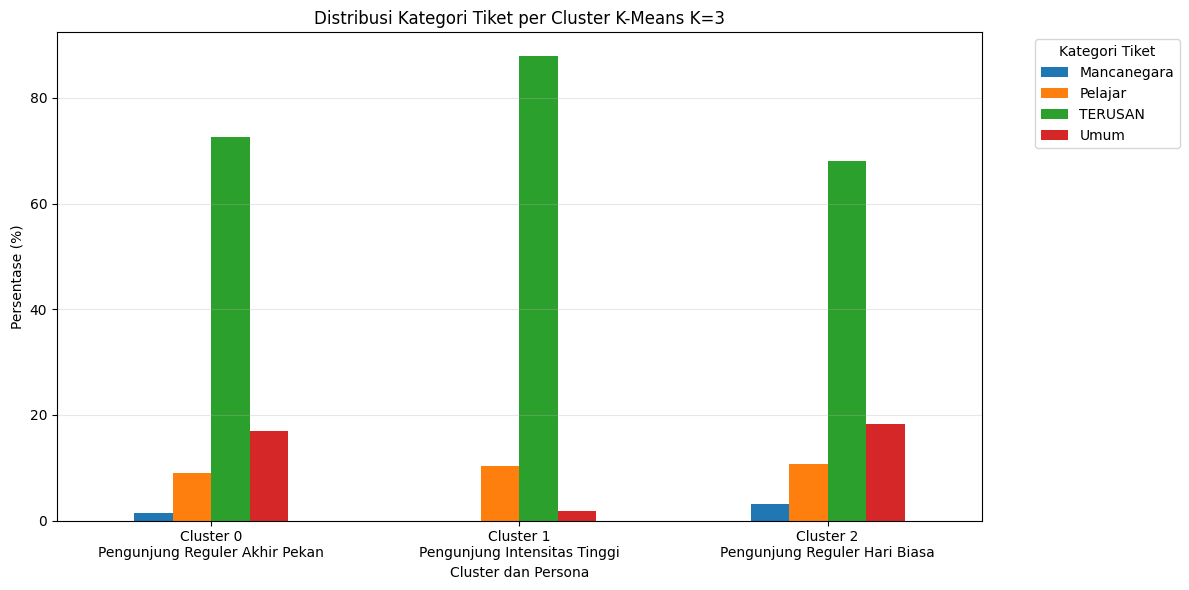


=== INTERPRETASI KATEGORI TIKET PER CLUSTER ===

Cluster 0 - Pengunjung Reguler Akhir Pekan
- Kategori tiket dominan: TERUSAN
- Persentase kategori dominan: 72.58%
Interpretasi: Cluster ini menunjukkan karakteristik transaksi reguler pada akhir pekan. Distribusi kategori tiket membantu melihat tipe kunjungan rekreasi yang lebih sering terjadi pada weekend.

Cluster 1 - Pengunjung Intensitas Tinggi
- Kategori tiket dominan: TERUSAN
- Persentase kategori dominan: 88.0%
Interpretasi: Cluster ini menunjukkan transaksi dengan intensitas tinggi. Kategori tiket dominan dapat digunakan untuk memahami jenis pembelian yang paling sering muncul pada transaksi rombongan atau kelompok besar.

Cluster 2 - Pengunjung Reguler Hari Biasa
- Kategori tiket dominan: TERUSAN
- Persentase kategori dominan: 68.04%
Interpretasi: Cluster ini menunjukkan karakteristik transaksi reguler pada hari biasa. Distribusi kategori tiket membantu melihat tipe pengunjung yang lebih sering datang pada weekday.


In [ ]:
print("=== ANALISIS KATEGORI TIKET PER CLUSTER K-MEANS K=3 ===")

# VALIDASI VARIABEL PENTING

required_for_category_analysis = [
    "cluster_kmeans",
    "persona",
    "kategori"
]

missing_cols = [
    col for col in required_for_category_analysis
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Kolom berikut belum tersedia pada dataframe: {missing_cols}. "
        "Pastikan bagian profiling cluster sudah dijalankan terlebih dahulu."
    )

if "persona_mapping" not in globals():
    raise ValueError(
        "Variabel persona_mapping belum tersedia. "
        "Pastikan bagian profiling cluster k=3 sudah dijalankan."
    )

# JUMLAH TRANSAKSI KATEGORI TIKET PER CLUSTER

kategori_count = pd.crosstab(
    index=[
        df["cluster_kmeans"],
        df["persona"]
    ],
    columns=df["kategori"]
)

print("\n=== JUMLAH TRANSAKSI BERDASARKAN KATEGORI TIKET PER CLUSTER ===")
display(kategori_count)

# PERSENTASE KATEGORI TIKET PER CLUSTER

kategori_percentage = pd.crosstab(
    index=[
        df["cluster_kmeans"],
        df["persona"]
    ],
    columns=df["kategori"],
    normalize="index"
) * 100

print("\n=== PERSENTASE KATEGORI TIKET PER CLUSTER ===")
display(kategori_percentage.round(2))

# VERSI RINGKAS
kategori_summary_long = (
    kategori_percentage
    .round(2)
    .reset_index()
    .melt(
        id_vars=[
            "cluster_kmeans",
            "persona"
        ],
        var_name="kategori",
        value_name="persentase_%"
    )
    .sort_values(
        by=[
            "cluster_kmeans",
            "persentase_%"
        ],
        ascending=[
            True,
            False
        ]
    )
)

kategori_count_long = (
    kategori_count
    .reset_index()
    .melt(
        id_vars=[
            "cluster_kmeans",
            "persona"
        ],
        var_name="kategori",
        value_name="jumlah_transaksi"
    )
)

kategori_analysis_per_cluster = kategori_summary_long.merge(
    kategori_count_long,
    on=[
        "cluster_kmeans",
        "persona",
        "kategori"
    ],
    how="left"
)

kategori_analysis_per_cluster = kategori_analysis_per_cluster[
    [
        "cluster_kmeans",
        "persona",
        "kategori",
        "jumlah_transaksi",
        "persentase_%"
    ]
]

print("\n=== RINGKASAN KATEGORI TIKET PER CLUSTER UNTUK LAPORAN ===")
display(kategori_analysis_per_cluster)

# KATEGORI DOMINAN PER CLUSTER

dominant_category = (
    kategori_percentage
    .idxmax(axis=1)
    .reset_index()
)

dominant_category.columns = [
    "cluster_kmeans",
    "persona",
    "kategori_dominan"
]

dominant_category["persentase_kategori_dominan"] = (
    kategori_percentage
    .max(axis=1)
    .values
).round(2)

print("\n=== KATEGORI DOMINAN PER CLUSTER ===")
display(dominant_category)

# VISUALISASI KATEGORI TIKET PER CLUSTER

kategori_percentage_plot = kategori_percentage.copy()
kategori_percentage_plot.index = [
    f"Cluster {cluster_id}\n{persona}"
    for cluster_id, persona in kategori_percentage_plot.index
]

ax = kategori_percentage_plot.round(2).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribusi Kategori Tiket per Cluster K-Means K=3")
plt.xlabel("Cluster dan Persona")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(title="Kategori Tiket", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    VISUAL_DIR / "kategori_tiket_per_cluster_kmeans_k3.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# INTERPRETASI KATEGORI TIKET

print("\n=== INTERPRETASI KATEGORI TIKET PER CLUSTER ===")

for _, row in dominant_category.iterrows():
    cluster_id = row["cluster_kmeans"]
    persona = row["persona"]
    kategori_dominan = row["kategori_dominan"]
    persentase = row["persentase_kategori_dominan"]

    print(f"\nCluster {cluster_id} - {persona}")
    print(f"- Kategori tiket dominan: {kategori_dominan}")
    print(f"- Persentase kategori dominan: {persentase}%")

    if persona == "Pengunjung Intensitas Tinggi":
        print(
            "Interpretasi: Cluster ini menunjukkan transaksi dengan intensitas tinggi. "
            "Kategori tiket dominan dapat digunakan untuk memahami jenis pembelian "
            "yang paling sering muncul pada transaksi rombongan atau kelompok besar."
        )

    elif persona == "Pengunjung Reguler Hari Biasa":
        print(
            "Interpretasi: Cluster ini menunjukkan karakteristik transaksi reguler "
            "pada hari biasa. Distribusi kategori tiket membantu melihat tipe "
            "pengunjung yang lebih sering datang pada weekday."
        )

    elif persona == "Pengunjung Reguler Akhir Pekan":
        print(
            "Interpretasi: Cluster ini menunjukkan karakteristik transaksi reguler "
            "pada akhir pekan. Distribusi kategori tiket membantu melihat tipe "
            "kunjungan rekreasi yang lebih sering terjadi pada weekend."
        )

    else:
        print(
            "Interpretasi: Cluster ini perlu dianalisis lebih lanjut berdasarkan "
            "jumlah tiket, total transaksi, dan kategori tiket dominan."
        )

13. ANALISIS THRESHOLD TIKET

=== THRESHOLD TERBAIK BERDASARKAN KESESUAIAN DENGAN CLUSTER INTENSITAS TINGGI ===


,56
threshold,66.000000
accuracy,0.997599
precision,0.931818
recall,0.937143
f1_score,0.934473
jumlah_transaksi_di_atas_threshold,176.000000



=== TOP 10 KANDIDAT THRESHOLD ===


,threshold,accuracy,precision,recall,f1_score,jumlah_transaksi_di_atas_threshold
56,66,0.997599,0.931818,0.937143,0.934473,176
57,67,0.997599,0.941860,0.925714,0.933718,172
61,71,0.997599,0.969136,0.897143,0.931751,162
62,72,0.997599,0.969136,0.897143,0.931751,162
58,68,0.997495,0.946746,0.914286,0.930233,169
59,69,0.997495,0.946746,0.914286,0.930233,169
51,61,0.997286,0.890052,0.971429,0.928962,191
52,62,0.997286,0.894180,0.965714,0.928571,189
60,70,0.997390,0.946429,0.908571,0.927114,168
53,63,0.997181,0.893617,0.960000,0.925620,188


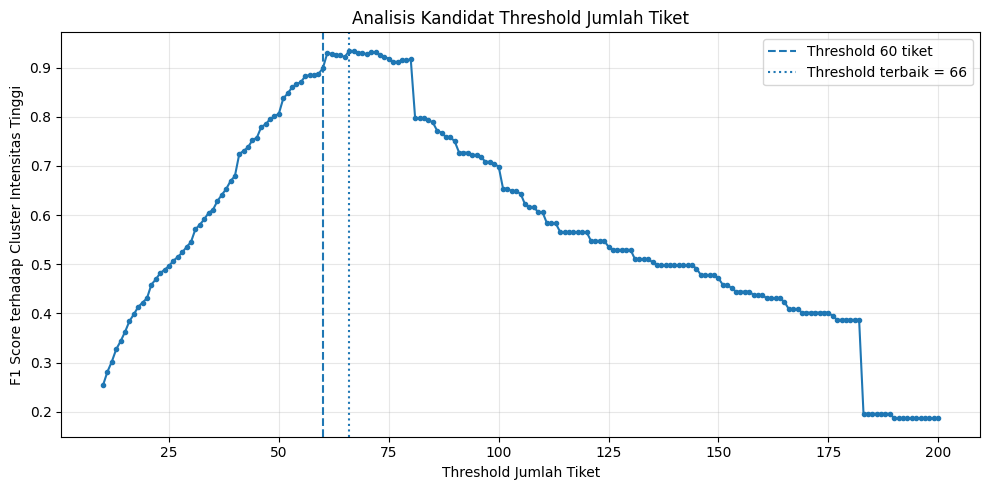

In [ ]:
# PENCARIAN THRESHOLD TERBAIK BERDASARKAN HASIL CLUSTER

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Cluster intensitas tinggi = cluster dengan rata-rata jumlah tiket tertinggi
high_intensity_cluster = df.groupby("cluster_kmeans")["jumlah"].mean().idxmax()

# Ground truth semu dari hasil clustering
# 1 = cluster intensitas tinggi, 0 = cluster reguler
y_cluster = (df["cluster_kmeans"] == high_intensity_cluster).astype(int)

threshold_results = []

for threshold in range(10, 201):
    y_threshold = (df["jumlah"] >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_cluster, y_threshold),
        "precision": precision_score(y_cluster, y_threshold, zero_division=0),
        "recall": recall_score(y_cluster, y_threshold, zero_division=0),
        "f1_score": f1_score(y_cluster, y_threshold, zero_division=0),
        "jumlah_transaksi_di_atas_threshold": y_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold = (
    threshold_results_df
    .sort_values(
        by=["f1_score", "precision", "recall"],
        ascending=[False, False, False]
    )
    .iloc[0]
)

print("=== THRESHOLD TERBAIK BERDASARKAN KESESUAIAN DENGAN CLUSTER INTENSITAS TINGGI ===")
display(best_threshold)

print("\n=== TOP 10 KANDIDAT THRESHOLD ===")
display(threshold_results_df.sort_values(
    by=["f1_score", "precision", "recall"],
    ascending=[False, False, False]
).head(10))

# Visualisasi F1 Score per threshold
plt.figure(figsize=(10, 5))
plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    marker="o",
    markersize=3
)

plt.axvline(
    x=60,
    linestyle="--",
    label="Threshold 60 tiket"
)

plt.axvline(
    x=best_threshold["threshold"],
    linestyle=":",
    label=f"Threshold terbaik = {int(best_threshold['threshold'])}"
)

plt.title("Analisis Kandidat Threshold Jumlah Tiket")
plt.xlabel("Threshold Jumlah Tiket")
plt.ylabel("F1 Score terhadap Cluster Intensitas Tinggi")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

14. SIMPAN MODEL, SCALER, DAN DATASET HASIL CLUSTERING

In [ ]:
print("=== SIMPAN MODEL, SCALER, DAN DATASET HASIL CLUSTERING K-MEANS K=3 ===")

# VALIDASI VARIABEL PENTING

required_variables = [
    "best_kmeans",
    "scaler",
    "df",
    "hpo_results",
    "elbow_df",
    "evaluation_kmeans",
    "cluster_profile_with_persona",
    "centroids_original",
    "kategori_count",
    "kategori_percentage",
    "dominant_category"
]

missing_variables = [
    var for var in required_variables
    if var not in globals()
]

if missing_variables:
    raise ValueError(
        f"Variabel berikut belum tersedia: {missing_variables}. "
        "Pastikan semua tahap sebelumnya sudah dijalankan."
    )

# VALIDASI CLUSTER DAN THRESHOLD FINAL

if best_kmeans.n_clusters != 3:
    print(
        "PERINGATAN: Model K-Means yang disimpan bukan k=3. "
        f"Jumlah cluster saat ini: {best_kmeans.n_clusters}"
    )

# Threshold final berdasarkan hasil pencarian threshold terbaik
if "best_threshold" in globals():
    FINAL_THRESHOLD = int(best_threshold["threshold"])
else:
    FINAL_THRESHOLD = 66

print(f"Jumlah cluster final      : {best_kmeans.n_clusters}")
print(f"Threshold empiris final   : {FINAL_THRESHOLD} tiket")

# Pastikan kolom threshold final tersedia
df["segmentasi_threshold_final"] = np.where(
    df["jumlah"] >= FINAL_THRESHOLD,
    f"Transaksi Intensitas Tinggi (>={FINAL_THRESHOLD} tiket)",
    f"Transaksi Reguler (<{FINAL_THRESHOLD} tiket)"
)

df["is_high_intensity_threshold_final"] = np.where(
    df["jumlah"] >= FINAL_THRESHOLD,
    1,
    0
)

# RINGKASAN THRESHOLD FINAL 66
threshold_final_distribution = (
    df["segmentasi_threshold_final"]
    .value_counts()
    .reset_index()
)

threshold_final_distribution.columns = [
    "segmentasi_threshold_final",
    "jumlah_transaksi"
]

threshold_final_distribution["persentase_%"] = (
    threshold_final_distribution["jumlah_transaksi"] / len(df) * 100
).round(2)

threshold_final_vs_cluster = pd.crosstab(
    index=[
        df["cluster_kmeans"],
        df["persona"]
    ],
    columns=df["segmentasi_threshold_final"],
    margins=True
)

threshold_final_vs_cluster_percentage = pd.crosstab(
    index=[
        df["cluster_kmeans"],
        df["persona"]
    ],
    columns=df["segmentasi_threshold_final"],
    normalize="index"
) * 100

threshold_final_summary_by_persona = (
    df
    .groupby([
        "cluster_kmeans",
        "persona"
    ])
    .agg(
        jumlah_transaksi=("cluster_kmeans", "count"),
        jumlah_transaksi_di_atas_threshold=("is_high_intensity_threshold_final", "sum"),
        rata_rata_tiket=("jumlah", "mean"),
        median_tiket=("jumlah", "median"),
        min_tiket=("jumlah", "min"),
        max_tiket=("jumlah", "max"),
        rata_rata_transaksi=("total", "mean"),
        median_transaksi=("total", "median")
    )
    .reset_index()
)

threshold_final_summary_by_persona["threshold_final"] = FINAL_THRESHOLD

threshold_final_summary_by_persona["persentase_di_atas_threshold_%"] = (
    threshold_final_summary_by_persona["jumlah_transaksi_di_atas_threshold"] /
    threshold_final_summary_by_persona["jumlah_transaksi"] * 100
).round(2)

threshold_final_summary_by_persona = threshold_final_summary_by_persona.round(2)

print("\n=== DISTRIBUSI THRESHOLD FINAL ===")
display(threshold_final_distribution)

print("\n=== THRESHOLD FINAL VS CLUSTER ===")
display(threshold_final_vs_cluster)

print("\n=== RINGKASAN THRESHOLD FINAL PER PERSONA ===")
display(threshold_final_summary_by_persona)

# PATH OUTPUT UTAMA UNTUK APLIKASI

MODEL_PATH = BASE_DIR / "kmeans_model.pkl"
SCALER_PATH = BASE_DIR / "scaler.pkl"
KMEANS_RESULT_PATH = BASE_DIR / "penjualan_tiket_kmeans.csv"

# PATH OUTPUT KHUSUS DOKUMENTASI REVISI K=3

KMEANS_K3_RESULT_PATH = BASE_DIR / "penjualan_tiket_kmeans_k3.csv"

ELBOW_K3_RESULT_PATH = BASE_DIR / "hasil_elbow_kmeans_k3.csv"
HPO_K3_RESULT_PATH = BASE_DIR / "hasil_hpo_kmeans_k3.csv"
EVALUASI_K3_PATH = BASE_DIR / "evaluasi_kmeans_k3.csv"

PROFIL_K3_PATH = BASE_DIR / "profil_cluster_kmeans_k3.csv"
CENTROID_K3_PATH = BASE_DIR / "centroid_kmeans_original_k3.csv"

KATEGORI_COUNT_K3_PATH = BASE_DIR / "kategori_tiket_count_kmeans_k3.csv"
KATEGORI_PERCENTAGE_K3_PATH = BASE_DIR / "kategori_tiket_percentage_kmeans_k3.csv"
KATEGORI_DOMINAN_K3_PATH = BASE_DIR / "kategori_dominan_kmeans_k3.csv"

THRESHOLD_FINAL_DISTRIBUTION_PATH = BASE_DIR / f"threshold_{FINAL_THRESHOLD}_distribution_kmeans_k3.csv"
THRESHOLD_FINAL_VS_CLUSTER_PATH = BASE_DIR / f"threshold_{FINAL_THRESHOLD}_vs_cluster_kmeans_k3.csv"
THRESHOLD_FINAL_VS_CLUSTER_PERCENTAGE_PATH = BASE_DIR / f"threshold_{FINAL_THRESHOLD}_vs_cluster_percentage_kmeans_k3.csv"
THRESHOLD_FINAL_SUMMARY_PERSONA_PATH = BASE_DIR / f"threshold_{FINAL_THRESHOLD}_summary_persona_kmeans_k3.csv"

THRESHOLD_CANDIDATE_RESULT_PATH = BASE_DIR / "threshold_candidate_results_kmeans_k3.csv"
BEST_THRESHOLD_PATH = BASE_DIR / "best_threshold_kmeans_k3.csv"

# SIMPAN MODEL DAN SCALER

joblib.dump(best_kmeans, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

# SIMPAN DATASET HASIL CLUSTERING

# File utama untuk aplikasi dashboard
df.to_csv(KMEANS_RESULT_PATH, index=False)

# File khusus dokumentasi revisi k=3
df.to_csv(KMEANS_K3_RESULT_PATH, index=False)

# SIMPAN HASIL ELBOW, HPO, DAN EVALUASI

elbow_df.to_csv(
    ELBOW_K3_RESULT_PATH,
    index=False
)

hpo_results.to_csv(
    HPO_K3_RESULT_PATH,
    index=False
)

evaluation_kmeans.to_csv(
    EVALUASI_K3_PATH,
    index=False
)

# SIMPAN PROFIL CLUSTER DAN CENTROID

cluster_profile_with_persona.to_csv(
    PROFIL_K3_PATH,
    index=True
)

centroids_original.to_csv(
    CENTROID_K3_PATH,
    index=False
)

# SIMPAN ANALISIS KATEGORI TIKET

kategori_count.to_csv(
    KATEGORI_COUNT_K3_PATH,
    index=True
)

kategori_percentage.round(2).to_csv(
    KATEGORI_PERCENTAGE_K3_PATH,
    index=True
)

dominant_category.to_csv(
    KATEGORI_DOMINAN_K3_PATH,
    index=False
)

# Jika variabel kategori_analysis_per_cluster tersedia, simpan juga
if "kategori_analysis_per_cluster" in globals():
    KATEGORI_ANALYSIS_K3_PATH = BASE_DIR / "kategori_tiket_analysis_kmeans_k3.csv"

    kategori_analysis_per_cluster.to_csv(
        KATEGORI_ANALYSIS_K3_PATH,
        index=False
    )

# SIMPAN ANALISIS THRESHOLD FINAL 66
threshold_final_distribution.to_csv(
    THRESHOLD_FINAL_DISTRIBUTION_PATH,
    index=False
)

threshold_final_vs_cluster.to_csv(
    THRESHOLD_FINAL_VS_CLUSTER_PATH,
    index=True
)

threshold_final_vs_cluster_percentage.round(2).to_csv(
    THRESHOLD_FINAL_VS_CLUSTER_PERCENTAGE_PATH,
    index=True
)

threshold_final_summary_by_persona.to_csv(
    THRESHOLD_FINAL_SUMMARY_PERSONA_PATH,
    index=False
)

# Simpan hasil pencarian kandidat threshold jika tersedia
if "threshold_results_df" in globals():
    threshold_results_df.to_csv(
        THRESHOLD_CANDIDATE_RESULT_PATH,
        index=False
    )

if "best_threshold" in globals():
    pd.DataFrame([best_threshold]).to_csv(
        BEST_THRESHOLD_PATH,
        index=False
    )

# SIMPAN INFORMASI RINGKAS FINAL

final_summary = pd.DataFrame({
    "keterangan": [
        "Jumlah cluster K-Means",
        "Threshold empiris transaksi intensitas tinggi",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Model operasional",
        "Fitur clustering"
    ],
    "nilai": [
        best_kmeans.n_clusters,
        FINAL_THRESHOLD,
        round(kmeans_silhouette, 6),
        round(kmeans_dbi, 6),
        round(kmeans_chi, 6),
        "K-Means Clustering k=3",
        ", ".join(features)
    ]
})

FINAL_SUMMARY_PATH = BASE_DIR / "ringkasan_final_kmeans_k3.csv"

final_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False
)

# ======================================================
# PRINT HASIL PENYIMPANAN
# ======================================================

print("\n=== FILE BERHASIL DISIMPAN ===")

print("\n[MODEL DAN DATASET UNTUK APLIKASI]")
print(f"Model K-Means utama                  : {MODEL_PATH}")
print(f"Scaler utama                         : {SCALER_PATH}")
print(f"Dataset hasil K-Means utama          : {KMEANS_RESULT_PATH}")
print(f"Dataset hasil K-Means k=3            : {KMEANS_K3_RESULT_PATH}")

print("\n[HASIL MODELING DAN EVALUASI]")
print(f"Hasil Elbow Method k=3               : {ELBOW_K3_RESULT_PATH}")
print(f"Hasil HPO K-Means k=3                : {HPO_K3_RESULT_PATH}")
print(f"Evaluasi K-Means k=3                 : {EVALUASI_K3_PATH}")
print(f"Ringkasan final K-Means k=3          : {FINAL_SUMMARY_PATH}")

print("\n[PROFIL CLUSTER]")
print(f"Profil cluster K-Means k=3           : {PROFIL_K3_PATH}")
print(f"Centroid asli K-Means k=3            : {CENTROID_K3_PATH}")

print("\n[ANALISIS KATEGORI TIKET]")
print(f"Kategori tiket count k=3             : {KATEGORI_COUNT_K3_PATH}")
print(f"Kategori tiket percentage k=3        : {KATEGORI_PERCENTAGE_K3_PATH}")
print(f"Kategori dominan k=3                 : {KATEGORI_DOMINAN_K3_PATH}")

if "kategori_analysis_per_cluster" in globals():
    print(f"Analisis kategori tiket k=3          : {KATEGORI_ANALYSIS_K3_PATH}")

print("\n[ANALISIS THRESHOLD FINAL]")
print(f"Threshold final                      : {FINAL_THRESHOLD} tiket")
print(f"Threshold distribution               : {THRESHOLD_FINAL_DISTRIBUTION_PATH}")
print(f"Threshold vs cluster                 : {THRESHOLD_FINAL_VS_CLUSTER_PATH}")
print(f"Threshold vs cluster percentage      : {THRESHOLD_FINAL_VS_CLUSTER_PERCENTAGE_PATH}")
print(f"Threshold summary persona            : {THRESHOLD_FINAL_SUMMARY_PERSONA_PATH}")

if "threshold_results_df" in globals():
    print(f"Hasil kandidat threshold             : {THRESHOLD_CANDIDATE_RESULT_PATH}")

if "best_threshold" in globals():
    print(f"Threshold terbaik                    : {BEST_THRESHOLD_PATH}")

print("\n[VISUALISASI]")
print(f"Folder visualisasi                   : {VISUAL_DIR}")

print("\n=== RINGKASAN AKHIR K-MEANS K=3 ===")
print(f"Jumlah cluster                       : {best_kmeans.n_clusters}")
print(f"Threshold empiris final              : {FINAL_THRESHOLD} tiket")
print(f"Silhouette Score                     : {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index                 : {kmeans_dbi:.4f}")
print(f"Calinski-Harabasz Index              : {kmeans_chi:.4f}")

print("\n=== DISTRIBUSI PERSONA FINAL ===")
display(df["persona"].value_counts())

print("\n=== RINGKASAN FINAL ===")
display(final_summary)

=== SIMPAN MODEL, SCALER, DAN DATASET HASIL CLUSTERING K-MEANS K=3 ===
Jumlah cluster final      : 3
Threshold empiris final   : 66 tiket

=== DISTRIBUSI THRESHOLD FINAL ===


,segmentasi_threshold_final,jumlah_transaksi,persentase_%
0,Transaksi Reguler (<66 tiket),9403,98.16
1,Transaksi Intensitas Tinggi (>=66 tiket),176,1.84



=== THRESHOLD FINAL VS CLUSTER ===


,segmentasi_threshold_final,Transaksi Intensitas Tinggi (>=66 tiket),Transaksi Reguler (<66 tiket),All
cluster_kmeans,persona,,,
0,Pengunjung Reguler Akhir Pekan,2,4148,4150
1,Pengunjung Intensitas Tinggi,164,11,175
2,Pengunjung Reguler Hari Biasa,10,5244,5254
All,,176,9403,9579



=== RINGKASAN THRESHOLD FINAL PER PERSONA ===


,cluster_kmeans,persona,jumlah_transaksi,jumlah_transaksi_di_atas_threshold,rata_rata_tiket,median_tiket,min_tiket,max_tiket,rata_rata_transaksi,median_transaksi,threshold_final,persentase_di_atas_threshold_%
0,0,Pengunjung Reguler Akhir Pekan,4150,2,5.79,3.0,1,67,119787.95,75000.0,66,0.05
1,1,Pengunjung Intensitas Tinggi,175,164,125.85,100.0,55,470,2476842.86,2000000.0,66,93.71
2,2,Pengunjung Reguler Hari Biasa,5254,10,5.24,3.0,1,80,106713.93,60000.0,66,0.19



=== FILE BERHASIL DISIMPAN ===

[MODEL DAN DATASET UNTUK APLIKASI]
Model K-Means utama                  : /content/drive/MyDrive/Clustering_TA_Revision/kmeans_model.pkl
Scaler utama                         : /content/drive/MyDrive/Clustering_TA_Revision/scaler.pkl
Dataset hasil K-Means utama          : /content/drive/MyDrive/Clustering_TA_Revision/penjualan_tiket_kmeans.csv
Dataset hasil K-Means k=3            : /content/drive/MyDrive/Clustering_TA_Revision/penjualan_tiket_kmeans_k3.csv

[HASIL MODELING DAN EVALUASI]
Hasil Elbow Method k=3               : /content/drive/MyDrive/Clustering_TA_Revision/hasil_elbow_kmeans_k3.csv
Hasil HPO K-Means k=3                : /content/drive/MyDrive/Clustering_TA_Revision/hasil_hpo_kmeans_k3.csv
Evaluasi K-Means k=3                 : /content/drive/MyDrive/Clustering_TA_Revision/evaluasi_kmeans_k3.csv
Ringkasan final K-Means k=3          : /content/drive/MyDrive/Clustering_TA_Revision/ringkasan_final_kmeans_k3.csv

[PROFIL CLUSTER]
Profil cluster 

,count
persona,
Pengunjung Reguler Hari Biasa,5254
Pengunjung Reguler Akhir Pekan,4150
Pengunjung Intensitas Tinggi,175



=== RINGKASAN FINAL ===


,keterangan,nilai
0,Jumlah cluster K-Means,3
1,Threshold empiris transaksi intensitas tinggi,66
2,Silhouette Score,0.341098
3,Davies-Bouldin Index,1.108475
4,Calinski-Harabasz Index,4068.767829
5,Model operasional,K-Means Clustering k=3
6,Fitur clustering,"jumlah, total, harga_per_tiket, is_weekend, jam"
